In [4]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [5]:
cd C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\12.drep\drep_Pvulgatus\01.bakta

C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\12.drep\drep_Pvulgatus\01.bakta


In [6]:
# =========================
# Input / output
# =========================
BAKTA_DIR = 'C02_concoct.31'
MAG_NAME = 'C02_concoct.31'

BAKTA_TSV = os.path.join(BAKTA_DIR, f"{MAG_NAME}.tsv")
BAKTA_GFF = os.path.join(BAKTA_DIR, f"{MAG_NAME}.gff3")

OUT_DIR = "bakta_python_plots"
os.makedirs(OUT_DIR, exist_ok=True)

sns.set_context("talk")
sns.set_style("white")

In [7]:
def parse_gff_attributes(attr):
    d = {}
    if pd.isna(attr):
        return d
    for item in str(attr).split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            d[k] = v
    return d


def read_bakta_gff(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Bakta GFF3 not found: {path}")

    rows = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue

            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue

            seqid, source, ftype, start, end, score, strand, phase, attrs = parts
            attr_dict = parse_gff_attributes(attrs)

            rows.append({
                "Sequence_ID": seqid,
                "Source": source,
                "Type": ftype,
                "Start": int(start),
                "End": int(end),
                "Strand": strand,
                "ID": attr_dict.get("ID", ""),
                "Name": attr_dict.get("Name", ""),
                "Product": attr_dict.get("product", attr_dict.get("Product", "")),
                "Gene": attr_dict.get("gene", ""),
                "Dbxref": attr_dict.get("Dbxref", ""),
                "Attributes": attrs
            })

    df = pd.DataFrame(rows)
    df["Length"] = df["End"] - df["Start"] + 1

    return df


gff_df = read_bakta_gff(BAKTA_GFF)
print(gff_df.head())
print(gff_df["Type"].value_counts())

  Sequence_ID       Source    Type  Start     End Strand            ID  \
0    contig_1        Bakta  region      1  347337      +      contig_1   
1    contig_1  tRNAscan-SE    tRNA    141     215      -  IIJEOF_00001   
2    contig_1    Pyrodigal     CDS    358    1647      +  IIJEOF_00002   
3    contig_1    Pyrodigal     CDS   1690    2526      +  IIJEOF_00003   
4    contig_1    Pyrodigal     CDS   3001    5073      -  IIJEOF_00004   

                                    Name  \
0                               contig_1   
1                          tRNA-Glu(ttc)   
2                Porin subfamily protein   
3                   deoxyribonuclease IV   
4  MarR family transcriptional regulator   

                                 Product  Gene  \
0                                                
1                          tRNA-Glu(ttc)  trnE   
2                Porin subfamily protein         
3                   deoxyribonuclease IV   nfo   
4  MarR family transcriptional regulator

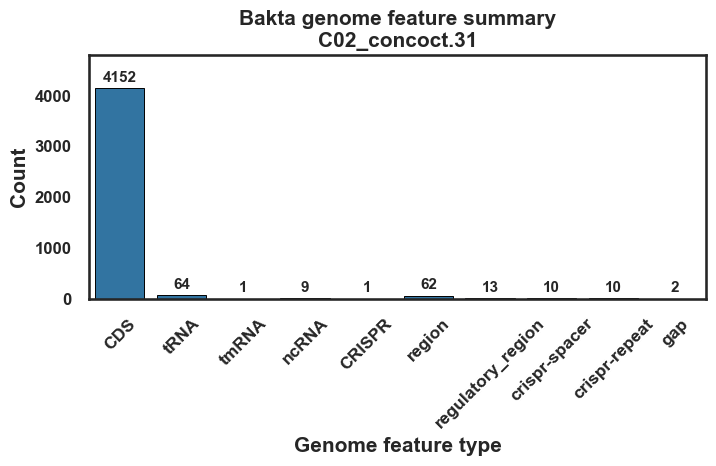

In [10]:
# =========================
# Feature type count
# =========================
feature_order = [
    "CDS", "tRNA", "rRNA", "tmRNA", "ncRNA",
    "repeat_region", "CRISPR", "oriC", "oriV", "oriT"
]

feature_counts = (
    gff_df["Type"]
    .value_counts()
    .rename_axis("Feature_type")
    .reset_index(name="Count")
)

# 보기 좋은 순서
feature_counts["Feature_type"] = feature_counts["Feature_type"].astype(str)
feature_counts["Order"] = feature_counts["Feature_type"].apply(
    lambda x: feature_order.index(x) if x in feature_order else 999
)
feature_counts = feature_counts.sort_values(["Order", "Count"], ascending=[True, False]).drop(columns="Order")

plt.figure(figsize=(7.5, 5))

ax = sns.barplot(
    data=feature_counts,
    x="Feature_type",
    y="Count",
    edgecolor="black",
    linewidth=0.7
)

for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        h + max(feature_counts["Count"]) * 0.015,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.xlabel("Genome feature type", fontsize=15, fontweight="bold")
plt.ylabel("Count", fontsize=15, fontweight="bold")
plt.title(f"Bakta genome feature summary\n{MAG_NAME}", fontsize=15, fontweight="bold")

y0, y1 = ax.get_ylim()
plt.ylim(y0,y1*1.1)

plt.xticks(fontsize=12.5, fontweight='bold', rotation=45)
plt.yticks(fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "Bakta_feature_type_counts.png"), dpi=500, bbox_inches="tight")
plt.show()

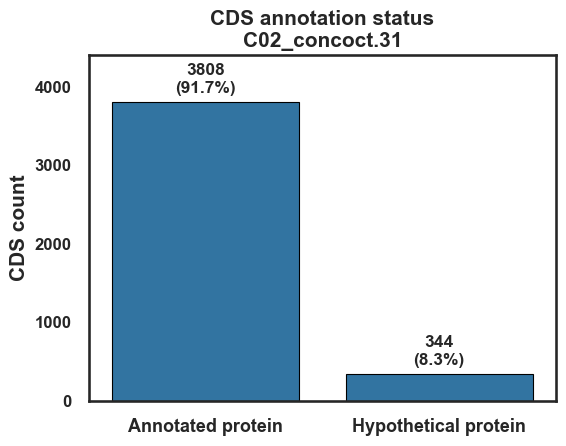

In [15]:
# =========================
# CDS annotation status
# =========================
cds_df = gff_df[gff_df["Type"] == "CDS"].copy()

def classify_cds_product(product):
    p = str(product).lower()
    if p.strip() == "" or "hypothetical protein" in p or p == "nan":
        return "Hypothetical protein"
    return "Annotated protein"

cds_df["Annotation_status"] = cds_df["Product"].apply(classify_cds_product)

status_counts = (
    cds_df["Annotation_status"]
    .value_counts()
    .rename_axis("Annotation_status")
    .reset_index(name="Count")
)

status_counts["Percent"] = status_counts["Count"] / status_counts["Count"].sum() * 100

plt.figure(figsize=(6, 4.8))

ax = sns.barplot(
    data=status_counts,
    x="Annotation_status",
    y="Count",
    edgecolor="black",
    linewidth=0.8
)

for p, pct in zip(ax.patches, status_counts["Percent"]):
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        h + max(status_counts["Count"]) * 0.02,
        f"{int(h)}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=12.5,
        fontweight="bold"
    )

plt.xlabel("")
plt.ylabel("CDS count", fontsize=15, fontweight="bold")
plt.title(f"CDS annotation status\n{MAG_NAME}", fontsize=15, fontweight="bold")

y0, y1 = ax.get_ylim()
plt.ylim(y0,y1*1.1)

plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "Bakta_CDS_annotation_status.png"), dpi=500, bbox_inches="tight")
plt.show()

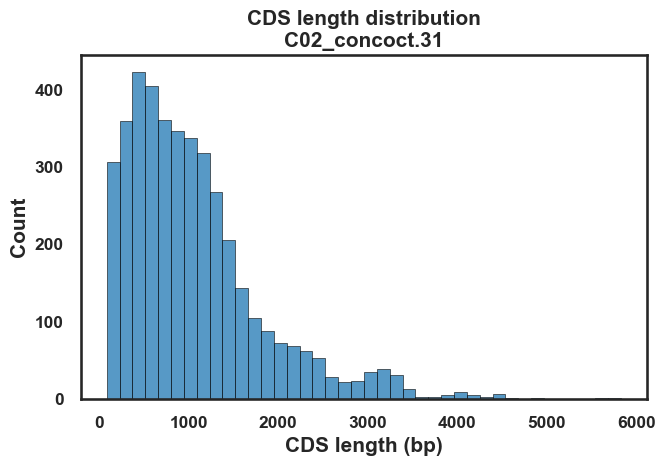

In [18]:
# =========================
# CDS length distribution
# =========================
cds_df["Length"] = pd.to_numeric(cds_df["Length"], errors="coerce")
plot_cds = cds_df.dropna(subset=["Length"]).copy()

plt.figure(figsize=(7, 5))

ax = sns.histplot(
    data=plot_cds,
    x="Length",
    bins=40,
    edgecolor="black",
    linewidth=0.4
)

plt.xlabel("CDS length (bp)", fontsize=15, fontweight="bold")
plt.ylabel("Count", fontsize=15, fontweight="bold")
plt.title(f"CDS length distribution\n{MAG_NAME}", fontsize=15, fontweight="bold")

plt.xticks(fontsize=12.5, fontweight='bold')
plt.yticks(fontsize=12.5, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "Bakta_CDS_length_distribution.png"), dpi=500, bbox_inches="tight")
plt.show()

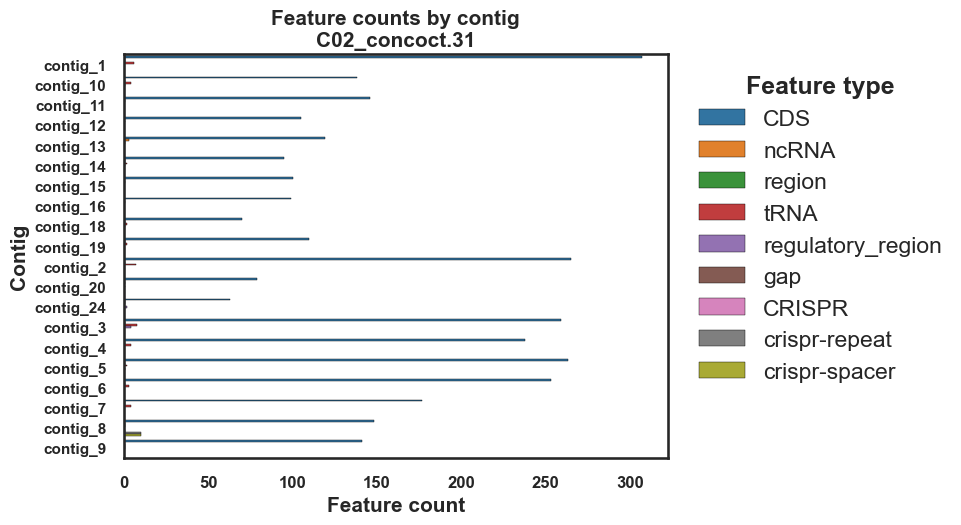

In [23]:
# =========================
# Feature counts by contig
# =========================
TOP_CONTIG = 20

contig_counts = (
    gff_df
    .groupby(["Sequence_ID", "Type"])
    .size()
    .reset_index(name="Count")
)

# contig total 기준 top contig 선정
top_contigs = (
    contig_counts
    .groupby("Sequence_ID")["Count"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_CONTIG)
    .index
)

contig_plot = contig_counts[contig_counts["Sequence_ID"].isin(top_contigs)].copy()

plt.figure(figsize=(10, max(5, TOP_CONTIG * 0.28)))

ax = sns.barplot(
    data=contig_plot,
    y="Sequence_ID",
    x="Count",
    hue="Type",
    edgecolor="black",
    linewidth=0.3
)

plt.xlabel("Feature count", fontsize=15, fontweight="bold")
plt.ylabel("Contig", fontsize=15, fontweight="bold")
plt.title(f"Feature counts by contig\n{MAG_NAME}", fontsize=15, fontweight="bold")

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

leg = ax.legend(title="Feature type", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
leg.get_title().set_fontweight("bold")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "Bakta_feature_counts_by_contig.png"), dpi=500, bbox_inches="tight")
plt.show()

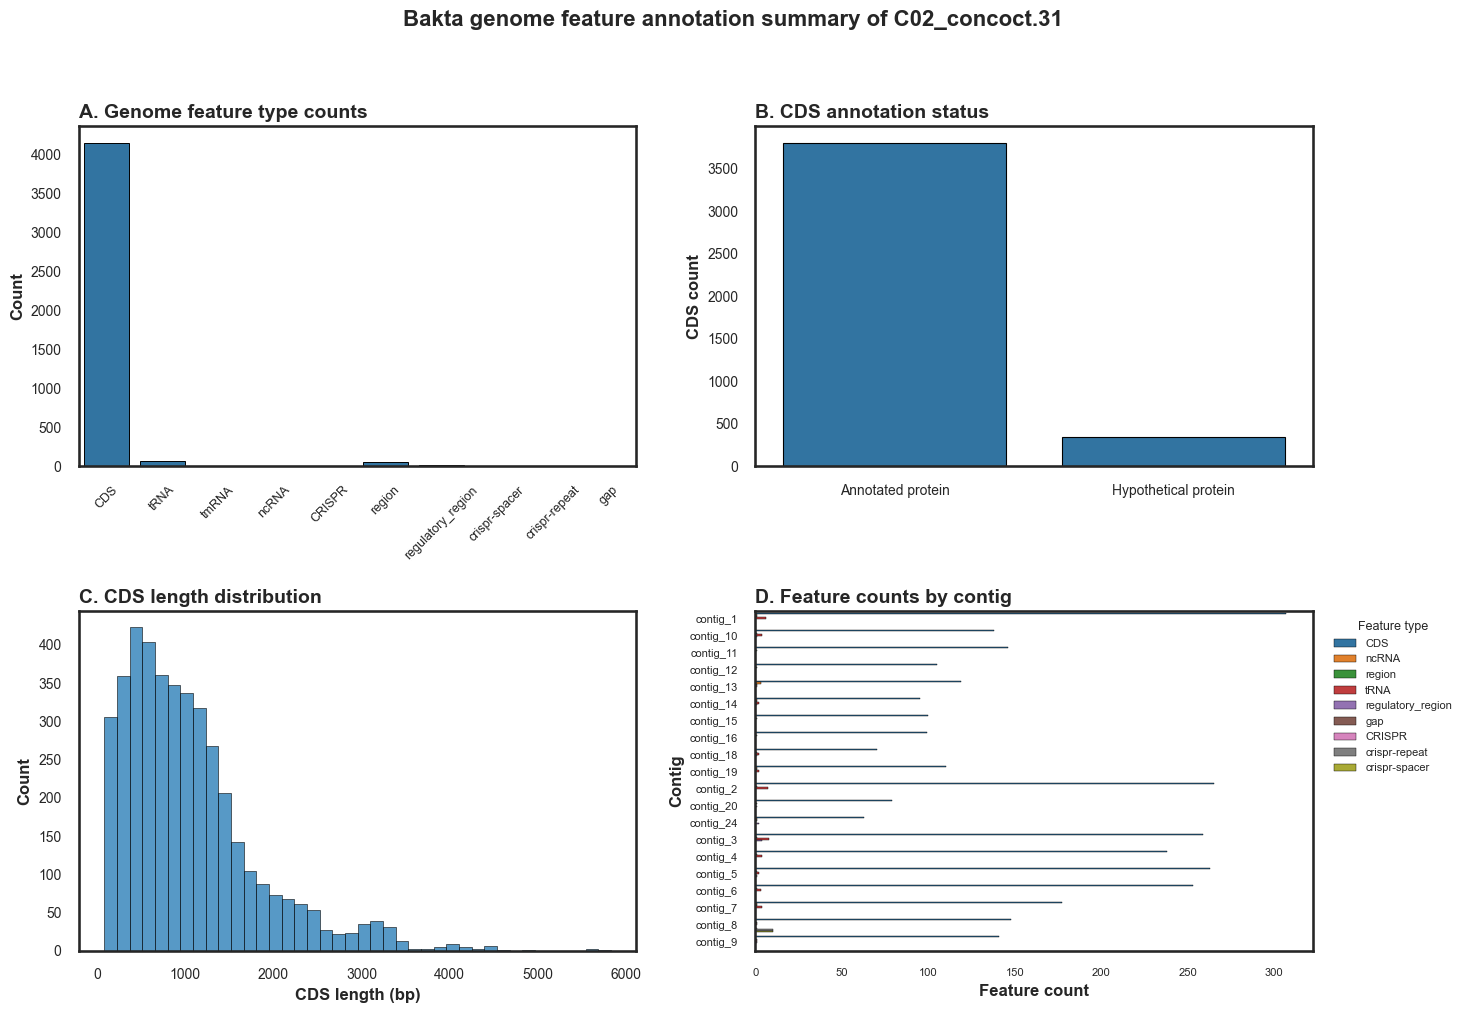

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# A
ax = axes[0, 0]
sns.barplot(data=feature_counts, x="Feature_type", y="Count", edgecolor="black", linewidth=0.7, ax=ax)
ax.set_title("A. Genome feature type counts", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("")
ax.set_ylabel("Count", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=10)

# B
ax = axes[0, 1]
sns.barplot(data=status_counts, x="Annotation_status", y="Count", edgecolor="black", linewidth=0.8, ax=ax)
ax.set_title("B. CDS annotation status", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("")
ax.set_ylabel("CDS count", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

# C
ax = axes[1, 0]
sns.histplot(data=plot_cds, x="Length", bins=40, edgecolor="black", linewidth=0.4, ax=ax)
ax.set_title("C. CDS length distribution", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("CDS length (bp)", fontsize=12, fontweight="bold")
ax.set_ylabel("Count", fontsize=12, fontweight="bold")
ax.tick_params(axis="both", labelsize=10)

# D
ax = axes[1, 1]
sns.barplot(data=contig_plot, y="Sequence_ID", x="Count", hue="Type", edgecolor="black", linewidth=0.3, ax=ax)
ax.set_title("D. Feature counts by contig", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("Feature count", fontsize=12, fontweight="bold")
ax.set_ylabel("Contig", fontsize=12, fontweight="bold")
ax.tick_params(axis="both", labelsize=8)
ax.legend(title="Feature type", frameon=False, fontsize=8, title_fontsize=9, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle(f"Bakta genome feature annotation summary of {MAG_NAME}", fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "Bakta_combined_panel.png"), dpi=500, bbox_inches="tight")
plt.show()